# Análisis Inteligente de Colores en Imágenes - Método del Codo (Elbow Method)

Este notebook contiene la implementación completa y profesional para analizar el espectro cromático de una imagen, reduciendo su paleta mediante **K-Means Clustering** y determinando científicamente el número óptimo de colores ($K$) utilizando el **Método del Codo**.


In [1]:
import os
import requests
from io import BytesIO
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Configurar el estilo visual (estilo Economist/Colorblind)
sns.set_theme(style='whitegrid', palette='colorblind')

### Carga y Preprocesamiento de Imágenes

Definimos una función para cargar la imagen (ya sea local o desde una URL) y transformar sus píxeles en una matriz RGB normalizada de dos dimensiones $(N \times 3)$, la cual es requerida por los algoritmos de clustering.

In [2]:
def cargar_y_preprocesar(ruta_o_url, max_size=(100, 100)):
    """
    Carga una imagen y la reduce de tamaño para acelerar el cálculo de K-Means,
    luego extrae y normaliza los canales RGB.
    """
    if ruta_o_url.startswith('http'):
        response = requests.get(ruta_o_url)
        img = Image.open(BytesIO(response.content))
    else:
        if not os.path.exists(ruta_o_url):
            # Generar imagen sintética de prueba si el archivo local no existe
            print(f"Archivo {ruta_o_url} no encontrado. Creando una imagen sintética de prueba...")
            img = Image.fromarray((np.random.rand(300, 300, 3) * 255).astype('uint8'))
        else:
            img = Image.open(ruta_o_url)

    img = img.convert('RGB')
    # Redimensionamos para que el algoritmo sea ultra rápido sin perder distribución cromática
    img.thumbnail(max_size)
    
    # Convertimos a arreglo NumPy y normalizamos al rango [0, 1]
    data = np.array(img) / 255.0
    w, h, d = data.shape
    pixels = data.reshape((w * h, d))    
    return img, pixels, (w,h,d)


### Implementación del Método del Codo (Elbow Method)
Calculamos la inercia (Suma de Errores al Cuadrado - SSE) para diferentes valores de $K$ (de 2 a 10) para encontrar el punto de inflexión donde la ganancia marginal de añadir más clústeres decrece.

In [3]:
def ejecutar_metodo_codo(pixels, k_min=2, k_max=10):
    sse = []
    k_values = list(range(k_min, k_max + 1))
    
    for k in k_values:
        # Usamos k-means++ para garantizar convergencia rápida y óptima
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(pixels)
        sse.append(kmeans.inertia_)
        print(f"K={k:2d} -> Inercia (SSE): {kmeans.inertia_:.4f}")
        
    return k_values, sse

### Selección Científica del $K$ Óptimo (Distancia Ortogonal)
Para evitar decisiones puramente subjetivas, implementamos el algoritmo de distancia ortogonal. Traza una recta entre el primer punto $(K=2)$ y el último $(K=10)$ de la curva de inercia, y encuentra el punto $K$ que se encuentra a la máxima distancia perpendicular de dicha recta.

In [4]:
def encontrar_k_optimo(k_values, sse):
    # 1. p1 es el PRIMER punto de la curva (K inicial)
    p1 = np.array([k_values[0], sse[0]])
    
    # 2. p2 es el ÚLTIMO punto de la curva (K final)
    p2 = np.array([k_values[-1], sse[-1]])
    
    distancias = []
    for i in range(len(k_values)):
        p = np.array([k_values[i], sse[i]])
        
        # Vectores en 2D
        v1 = p2 - p1  # Dirección de la línea de referencia
        v2 = p1 - p   # Dirección desde el punto actual al inicio
        
        # Producto cruz manual en 2D: (u_x * v_y) - (u_y * v_x)
        num = np.abs(v1[0] * v2[1] - v1[1] * v2[0])
        den = np.linalg.norm(p2 - p1)
        
        distancias.append(num / den)
        
    # Guardamos el índice del máximo para devolverlo también
    idx_max = np.argmax(distancias)
    return k_values[idx_max], idx_max  # Devolvemos (valor_K, posición)

### Cuantización de Colores y Visualización de Resultados
Ejecutamos K-Means final con el $K$ óptimo, mapeamos cada píxel a su centroide más cercano, extraemos los códigos HEX y visualizamos todo lado a lado.

In [5]:
def rgb_a_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

def visualizar_resultados(img_original, pixels, k_optimo, k_values, sse):
    # Ajustar K-Means con el K óptimo
    kmeans_opt = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42, n_init=10)
    kmeans_opt.fit(pixels)
    
    # Reconstruir imagen reducida
    centroides = kmeans_opt.cluster_centers_
    labels = kmeans_opt.labels_
    
    pixels_reducidos = centroides[labels]
    # Re-escalar a dimensiones de la imagen reducida para mostrar
    w_r, h_r = img_original.size
    img_reducida = (pixels_reducidos.reshape((h_r, w_r, 3)) * 255).astype('uint8')
    
    # Obtener códigos HEX
    colores_hex = [rgb_a_hex(c) for c in centroides]
    
    # Configurar gráficos
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    plt.suptitle(f"Análisis de Color Inteligente (K Óptimo detectado = {k_optimo})", fontsize=16, fontweight='bold')
    
    # 1. Gráfico del Codo
    axs[0, 0].plot(k_values, sse, marker='o', color='#1f77b4', linewidth=2.5)
    axs[0, 0].axvline(x=k_optimo, color='#ff7f0e', linestyle='--', linewidth=2, label=f'K Óptimo ({k_optimo})')
    axs[0, 0].set_title("Curva del Codo (SSE vs K)", fontsize=12, fontweight='bold')
    axs[0, 0].set_xlabel("Número de Grupos (K)")
    axs[0, 0].set_ylabel("Inercia (SSE)")
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle=':', alpha=0.6)
    
    # 2. Paleta de Colores
    axs[0, 1].imshow([centroides], aspect='auto')
    axs[0, 1].set_title("Paleta de Colores Óptima Extraída", fontsize=12, fontweight='bold')
    axs[0, 1].set_xticks(range(len(colores_hex))),
    axs[0, 1].set_xticklabels(colores_hex, rotation=45, ha='right', fontsize=9)
    axs[0, 1].set_yticks([])
    
    # 3. Imagen Original
    axs[1, 0].imshow(img_original)
    axs[1, 0].set_title("Imagen Original (Resolución Reducida para Análisis)", fontsize=12, fontweight='bold')
    axs[1, 0].axis('off')
    
    # 4. Imagen Reducida
    axs[1, 1].imshow(img_reducida)
    axs[1, 1].set_title(f"Imagen Cuantizada con K={k_optimo} colores", fontsize=12, fontweight='bold')
    axs[1, 1].axis('off')
    
    plt.show()


### Ejecución del Flujo de Trabajo
Ejecuta esta celda para iniciar el proceso. Puedes cambiar la ruta de la imagen local por tu propia fotografía (por ejemplo, `'imagen1.jpg'`).


=== PALETA DE COLORES EXTRAÍDA ===
Color 1: RGB (np.int64(74), np.int64(61), np.int64(38)) -> Hexadecimal: #4A3D26
Color 2: RGB (np.int64(192), np.int64(177), np.int64(107)) -> Hexadecimal: #C0B16B


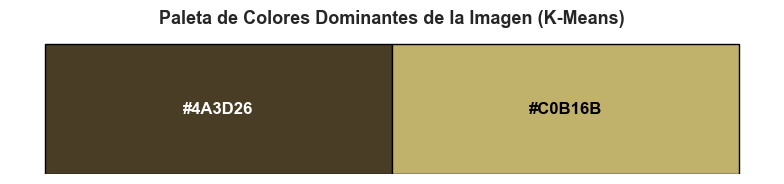

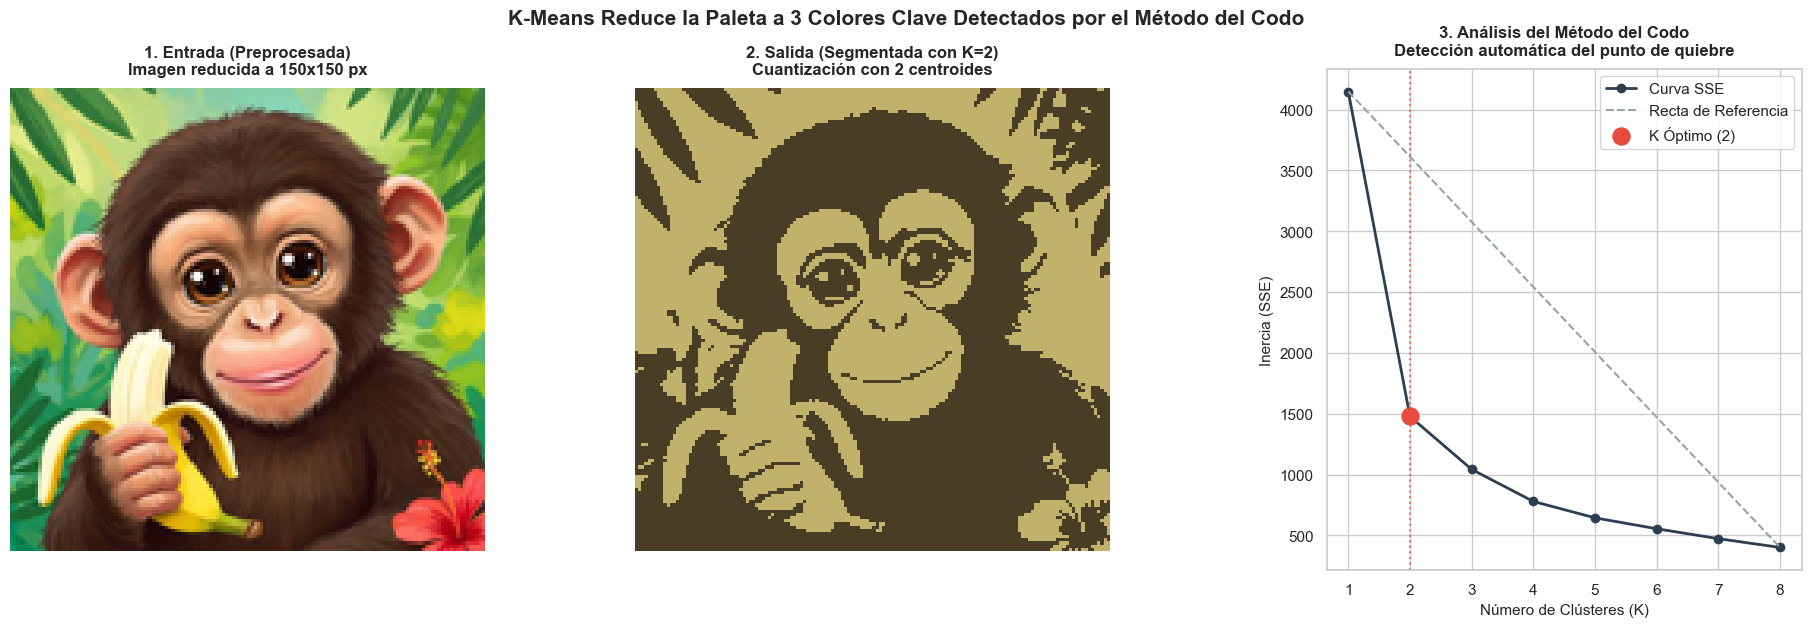

In [6]:
# Especificar el archivo de imagen localo una url
ruta_imagen = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRucbuVymAk-NqN-qz_P4XHCYmxfffOVthZc4BM3RmTycKSmgcQezgVnRwN&s=10'

img_original, pixels, (w, h, d) = cargar_y_preprocesar(ruta_imagen, max_size=(150, 150))

# Evaluar curva de codo
ks = list(range(1, 9))
sse_values = []
for k in ks:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans_temp.fit(pixels)
    sse_values.append(kmeans_temp.inertia_)

# Encontrar K óptimo
k_opt, idx_opt = encontrar_k_optimo(ks, sse_values)

# Entrenar K-Means definitivo
kmeans_definitivo = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans_definitivo.fit_predict(pixels)

# Los centroides contienen los colores en formato normalizado [0, 1]
centroids = kmeans_definitivo.cluster_centers_

# Multiplicamos por 255 y convertimos a enteros para obtener el RGB real [0, 255]
colores_rgb = (centroids * 255).astype(int)

# Convertimos cada color RGB a su código Hexadecimal (#RRGGBB)
colores_hex = []
for color in colores_rgb:
    r, g, b = color
    hex_code = f"#{r:02X}{g:02X}{b:02X}"
    colores_hex.append(hex_code)

# Imprimimos los códigos en texto
print("=== PALETA DE COLORES EXTRAÍDA ===")
for i, (rgb, hex_val) in enumerate(zip(colores_rgb, colores_hex)):
    print(f"Color {i+1}: RGB {tuple(rgb)} -> Hexadecimal: {hex_val}")

#¡Graficamos la paleta para que la veas visualmente!
fig, ax = plt.subplots(figsize=(8, 2))
# Dibujamos barras de color pegadas unas a otras
ax.bar(range(len(colores_hex)), [1]*len(colores_hex), color=colores_hex, width=1.0, edgecolor='black')

# Añadimos las etiquetas de texto de los códigos Hex encima de cada color
for i, hex_val in enumerate(colores_hex):
    # Determinamos si el fondo es muy claro u oscuro para elegir texto blanco o negro
    rgb = colores_rgb[i]
    luminancia = (0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2])
    color_texto = 'white' if luminancia < 128 else 'black'
    
    ax.text(i, 0.5, hex_val, ha='center', va='center', 
            color=color_texto, fontsize=12, fontweight='bold')

ax.set_title("Paleta de Colores Dominantes de la Imagen (K-Means)", fontsize=13, fontweight='bold', pad=10)
ax.axis('off') # Ocultamos los ejes
plt.tight_layout()
plt.show()


# Reconstruir imagen segmentada
pixels_segmented = centroids[labels]
img_salida_arr = (pixels_segmented.reshape((w, h, d)) * 255).astype(np.uint8)
img_salida = Image.fromarray(img_salida_arr)

# --- CREACIÓN DE LA GRÁFICA COMBINADA ---
fig = plt.figure(figsize=(18, 6), layout="constrained")
gs = fig.add_gridspec(1, 3, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# Panel 1: Entrada
ax1.imshow(img_original)
ax1.set_title("1. Entrada (Preprocesada)\nImagen reducida a 150x150 px", fontsize=12, fontweight='bold', pad=10)
ax1.axis('off')

# Panel 2: Salida
ax2.imshow(img_salida)
ax2.set_title(f"2. Salida (Segmentada con K={k_opt})\nCuantización con {k_opt} centroides", fontsize=12, fontweight='bold', pad=10)
ax2.axis('off')

# Panel 3: Curva de Codo
ax3.plot(ks, sse_values, marker='o', color='#2C3E50', linewidth=2, label="Curva SSE")
ax3.plot([ks[0], ks[-1]], [sse_values[0], sse_values[-1]], linestyle='--', color='#95A5A6', label="Recta de Referencia")
ax3.scatter(k_opt, sse_values[idx_opt], color='#E74C3C', s=150, zorder=5, label=f"K Óptimo ({k_opt})")
ax3.axvline(x=k_opt, color='#E74C3C', linestyle=':', alpha=0.7)

ax3.set_title("3. Análisis del Método del Codo\nDetección automática del punto de quiebre", fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel("Número de Clústeres (K)", fontsize=11)
ax3.set_ylabel("Inercia (SSE)", fontsize=11)
ax3.set_xticks(ks)
ax3.legend(frameon=True, facecolor='white')

plt.suptitle("K-Means Reduce la Paleta a 3 Colores Clave Detectados por el Método del Codo", fontsize=15, fontweight='bold', y=1.02)
plt.show()